# EDA on Pakistan_E-Commerce_Dataset_01

***Inspiration***
**Research Focus: Financial Friction & Order Fulfillment Audit**
The goal of this analysis is to identify systemic patterns in transaction failures
within the Pakistani e-commerce ecosystem. Specifically, we are investigating the
**"PKR 858M Inventory Crisis"**  examining how payment gateway performance and
temporal factors correlate with order cancellations, and which customer segments
are most at risk of churning.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

### Load the dataset

In [2]:
# low_memory=False silences the DtypeWarning on mixed-type columns
# parse_dates handles the two main datetime columns on load so we don't have to later
df = pd.read_csv(
    '/kaggle/input/pakistans-largest-ecommerce-dataset/Pakistan Largest Ecommerce Dataset.csv',
    low_memory=False,
    parse_dates=['created_at', 'Working Date']
)

# the raw file has ~460k completely empty rows appended at the bottom — drop them
df = df.iloc[:584524]

print(f"In this dataset numbers of rows {df.shape[0]} and numbers of columns {df.shape[1]}")

In this dataset numbers of rows 584524 and numbers of columns 26


In [3]:
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,2016-07-01,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,2016-07-01,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,2016-07-01,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
584519,905204.0,cod,2018-08-28,WOFSCE5AE00357AECDE,699.0,1.0,849.0,100562385,Women's Fashion,NaN,...,8.0,2018-8,8-2018,FY19,115320.0,NaN,NaN,NaN,NaN,NaN
584520,905205.0,processing,2018-08-28,MATHUA5AF70A7D1E50A,35599.0,1.0,35899.0,100562386,Mobiles & Tablets,NaN,...,8.0,2018-8,8-2018,FY19,115326.0,NaN,NaN,NaN,NaN,NaN
584521,905206.0,processing,2018-08-28,MATSAM5B6D7208C6D30,129999.0,2.0,652178.0,100562387,Mobiles & Tablets,NaN,...,8.0,2018-7,8-2018,FY19,113474.0,NaN,NaN,NaN,NaN,NaN
584522,905207.0,processing,2018-08-28,MATSAM5B1509B4696EA,87300.0,2.0,652178.0,100562387,Mobiles & Tablets,NaN,...,8.0,2018-7,8-2018,FY19,113474.0,NaN,NaN,NaN,NaN,NaN
584523,905208.0,processing,2018-08-28,MATSAM5B10F91A9B6AB,108640.0,2.0,652178.0,100562387,Mobiles & Tablets,NaN,...,8.0,2018-7,8-2018,FY19,113474.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584524 entries, 0 to 584523
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   item_id                584524 non-null  float64       
 1   status                 584509 non-null  object        
 2   created_at             584524 non-null  datetime64[ns]
 3   sku                    584504 non-null  object        
 4   price                  584524 non-null  float64       
 5   qty_ordered            584524 non-null  float64       
 6   grand_total            584524 non-null  float64       
 7   increment_id           584524 non-null  object        
 8   category_name_1        584360 non-null  object        
 9   sales_commission_code  447346 non-null  object        
 10  discount_amount        584524 non-null  float64       
 11  payment_method         584524 non-null  object        
 12  Working Date           584524 non-null  date

In [6]:
# summary of dataset
df.describe()

,item_id,created_at,price,qty_ordered,grand_total,discount_amount,Working Date,Year,Month,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,584524.000000,584524,5.845240e+05,584524.000000,5.845240e+05,584524.000000,584524,584524.000000,584524.000000,584513.000000,0.0,0.0,0.0,0.0,0.0
mean,565667.074218,2017-08-08 11:42:53.589450752,6.348748e+03,1.296388,8.530619e+03,499.492775,2017-08-08 11:42:53.589450752,2017.044115,7.167654,45790.511965,NaN,NaN,NaN,NaN,NaN
min,211131.000000,2016-07-01 00:00:00,0.000000e+00,1.000000,-1.594000e+03,-599.500000,2016-07-01 00:00:00,2016.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,395000.750000,2017-01-29 00:00:00,3.600000e+02,1.000000,9.450000e+02,0.000000,2017-01-29 00:00:00,2017.000000,4.000000,13516.000000,NaN,NaN,NaN,NaN,NaN
50%,568424.500000,2017-08-17 00:00:00,8.990000e+02,1.000000,1.960400e+03,0.000000,2017-08-17 00:00:00,2017.000000,7.000000,42856.000000,NaN,NaN,NaN,NaN,NaN
75%,739106.250000,2018-02-03 00:00:00,4.070000e+03,1.000000,6.999000e+03,160.500000,2018-02-03 00:00:00,2018.000000,11.000000,73536.000000,NaN,NaN,NaN,NaN,NaN
max,905208.000000,2018-08-28 00:00:00,1.012626e+06,1000.000000,1.788800e+07,90300.000000,2018-08-28 00:00:00,2018.000000,12.000000,115326.000000,NaN,NaN,NaN,NaN,NaN
std,200121.173648,NaN,1.494927e+04,3.996061,6.132081e+04,1506.943046,NaN,0.707355,3.486305,34414.962389,NaN,NaN,NaN,NaN,NaN


In [7]:
df.describe(include=["object"])

,status,sku,increment_id,category_name_1,sales_commission_code,payment_method,BI Status,MV,Customer Since,M-Y,FY
count,584509,584504,584524,584360,447346,584524,584524,584524,584513,584524,584524
unique,16,84889,408782,16,7225,18,4,9720,26,26,3
top,complete,MATSAM59DB75ADB2F80,100266667,Mobiles & Tablets,\N,cod,Net,999,2016-11,11-2017,FY18
freq,233685,3775,72,115710,339001,271960,234178,9516,82714,83928,306883


In [8]:
df.dtypes

item_id                         float64
status                           object
created_at               datetime64[ns]
sku                              object
price                           float64
qty_ordered                     float64
grand_total                     float64
increment_id                     object
category_name_1                  object
sales_commission_code            object
discount_amount                 float64
payment_method                   object
Working Date             datetime64[ns]
BI Status                        object
 MV                              object
Year                            float64
Month                           float64
Customer Since                   object
M-Y                              object
FY                               object
Customer ID                     float64
Unnamed: 21                     float64
Unnamed: 22                     float64
Unnamed: 23                     float64
Unnamed: 24                     float64


## Handle the missing values

In [9]:
df.isnull().sum()

item_id                       0
status                       15
created_at                    0
sku                          20
price                         0
qty_ordered                   0
grand_total                   0
increment_id                  0
category_name_1             164
sales_commission_code    137178
discount_amount               0
payment_method                0
Working Date                  0
BI Status                     0
 MV                           0
Year                          0
Month                         0
Customer Since               11
M-Y                           0
FY                            0
Customer ID                  11
Unnamed: 21              584524
Unnamed: 22              584524
Unnamed: 23              584524
Unnamed: 24              584524
Unnamed: 25              584524
dtype: int64

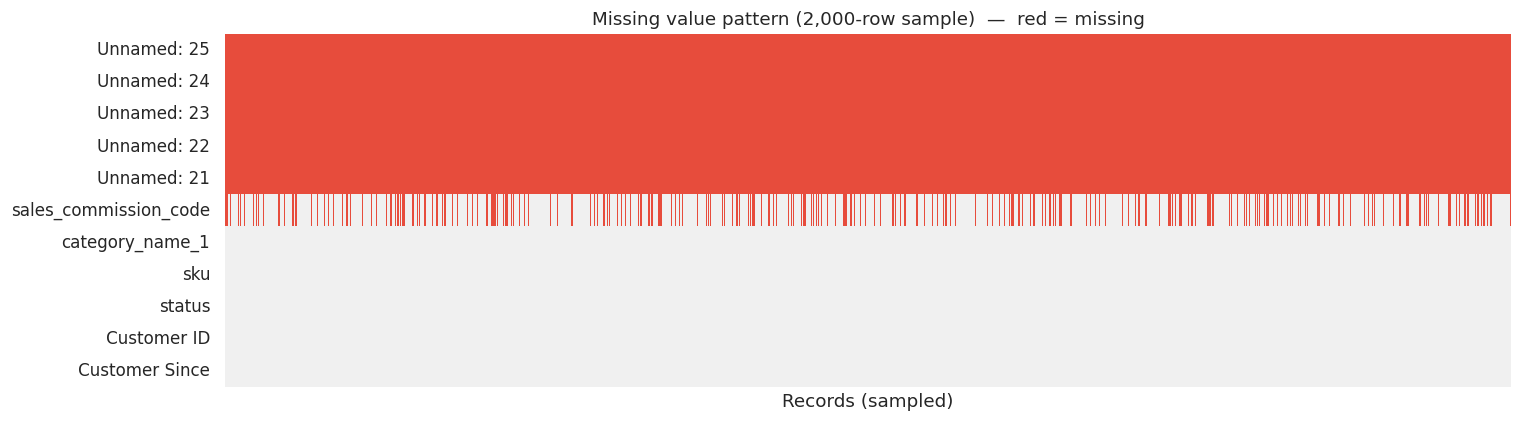

In [10]:
# heatmap gives a spatial view of where nulls sit across the dataset
# a bar chart only shows totals — it can't show whether nulls are clustered
# in certain rows or scattered randomly, which matters for deciding how to handle them
missing = df.isnull().sum().sort_values(ascending=False)
cols_with_nulls = missing[missing > 0].index.tolist()

fig, ax = plt.subplots(figsize=(14, 4))
null_matrix = df[cols_with_nulls].isnull().astype(int)
sns.heatmap(
    null_matrix.sample(2000, random_state=42).T,
    cbar=False,
    cmap=['#f0f0f0', '#e74c3c'],
    ax=ax,
    yticklabels=True,
    xticklabels=False
)
ax.set_title("Missing value pattern (2,000-row sample)  —  red = missing", fontsize=12)
ax.set_xlabel("Records (sampled)")
plt.tight_layout()
plt.show()

From the heatmap it is clear:
- the last 5 columns (`Unnamed: 21` through `Unnamed: 25`) are fully red — empty across every single row
- `sales_commission_code` has scattered but heavy missingness (~23.5%)
- every other column is mostly complete
#
We'll remove the empty columns first, then deal with the commission column separately.

In [11]:
# Define columns to drop
columns_to_drop = ["Unnamed: 21", "Unnamed: 22", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25"]
# Drop columns
df.drop(columns=columns_to_drop, inplace=True)

In [12]:
print(f"After remove columns , In this dataset numbers of rows {df.shape[0]} and numbers of columns {df.shape[1]}")

After remove columns , In this dataset numbers of rows 584524 and numbers of columns 21


In [13]:
df.isnull().sum()

item_id                       0
status                       15
created_at                    0
sku                          20
price                         0
qty_ordered                   0
grand_total                   0
increment_id                  0
category_name_1             164
sales_commission_code    137178
discount_amount               0
payment_method                0
Working Date                  0
BI Status                     0
 MV                           0
Year                          0
Month                         0
Customer Since               11
M-Y                           0
FY                            0
Customer ID                  11
dtype: int64

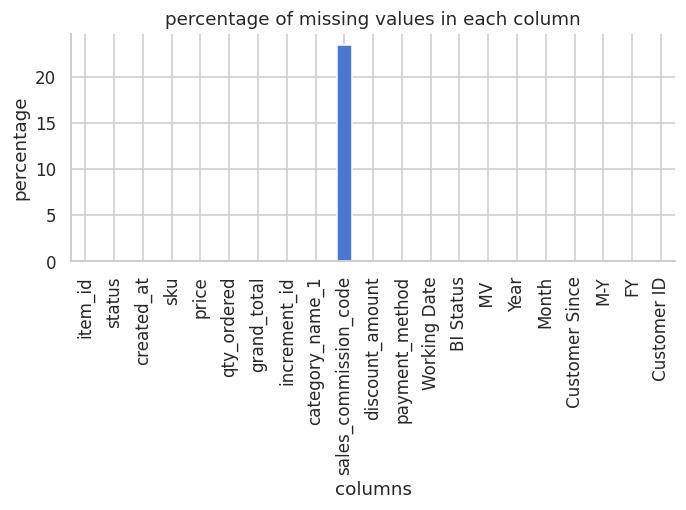

In [14]:
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage.plot(kind='bar')
# add labels
plt.xlabel('columns')
plt.ylabel('percentage')
plt.title("percentage of missing values in each column")
plt.tight_layout()
plt.show()

In [15]:
df.isnull().sum().sort_values(ascending=True)

item_id                       0
M-Y                           0
Month                         0
Year                          0
 MV                           0
BI Status                     0
Working Date                  0
payment_method                0
FY                            0
discount_amount               0
increment_id                  0
grand_total                   0
qty_ordered                   0
price                         0
created_at                    0
Customer Since               11
Customer ID                  11
status                       15
sku                          20
category_name_1             164
sales_commission_code    137178
dtype: int64

In [16]:
# Dropping the sales_commission_code column
# Also dropping redundant or highly missing columns identified in EDA
df.drop(columns=['sales_commission_code'], inplace=True, errors='ignore')

# Verification
print(f"Remaining nulls:\n{df.isnull().sum()}")

Remaining nulls:
item_id              0
status              15
created_at           0
sku                 20
price                0
qty_ordered          0
grand_total          0
increment_id         0
category_name_1    164
discount_amount      0
payment_method       0
Working Date         0
BI Status            0
 MV                  0
Year                 0
Month                0
Customer Since      11
M-Y                  0
FY                   0
Customer ID         11
dtype: int64


I have decided to drop the `sales_commission_code` column for the following reasons:

**High Missingness:** This column is missing 137,178 values (approximately 23.5% of the active dataset).
If I used `dropna()` on the full dataframe without removing this column first, I would lose over
137,000 valid transaction records that are essential for the payment audit and order status analysis.

**Low Domain Relevance:** My research focus is the Fintech Audit (Easypay failures) and the Loyalty Risk Index.
Sales commission codes are internal accounting markers — they tell us nothing about why a customer
cancels an order or how likely they are to churn.

**Data Integrity:** A feature with 23.5% nullity introduces noise into ML models and can produce
biased SHAP attributions in Phase 3.

In [17]:
df.shape

(584524, 20)

## Duplicate values

In [18]:
df.duplicated().sum()

0

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584524 entries, 0 to 584523
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   item_id          584524 non-null  float64       
 1   status           584509 non-null  object        
 2   created_at       584524 non-null  datetime64[ns]
 3   sku              584504 non-null  object        
 4   price            584524 non-null  float64       
 5   qty_ordered      584524 non-null  float64       
 6   grand_total      584524 non-null  float64       
 7   increment_id     584524 non-null  object        
 8   category_name_1  584360 non-null  object        
 9   discount_amount  584524 non-null  float64       
 10  payment_method   584524 non-null  object        
 11  Working Date     584524 non-null  datetime64[ns]
 12  BI Status        584524 non-null  object        
 13   MV              584524 non-null  object        
 14  Year             584

In [20]:
# 1. Drop rows with nulls in the four columns that are load-bearing for this audit
df.dropna(subset=['status', 'sku', 'category_name_1', 'Customer ID'], inplace=True)

# 2. Check the results
print(f"Total rows remaining: {len(df)}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Total rows remaining: 584314
Missing values remaining: 0


**Reason for Preprocessing:** The dropped rows represent less than 0.1% of the data.
Each of these four columns is critical for a different part of the analysis —
`status` defines whether an order failed, `sku` identifies the unsold inventory item,
`category_name_1` powers the per-category breakdown, and `Customer ID` is needed for RFM profiling.
Rows missing any of them can't contribute meaningful signal, so removing them is the right call.

In [21]:
# Removing redundant columns
# 'increment_id' is a string transaction ID with no numeric value
# ' MV ' is just a string copy of grand_total
# 'BI Status', 'M-Y', 'FY' are simplified time labels — we can get all of this from 'created_at'
cols_to_remove = ['increment_id', ' MV ', 'BI Status', 'M-Y', 'FY']
df.drop(columns=cols_to_remove, inplace=True, errors='ignore')

# Standardize column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

**Reason for Preprocessing:** `increment_id` and `MV` are redundant — one is a string label,
the other duplicates a numeric column we already have. `BI Status`, `M-Y`, and `FY` were removed
to reduce dimensionality; all the temporal information they contain can be extracted more precisely
from `created_at` during feature engineering.

In [22]:
# re-parse any datetime columns that may have slipped through as object after the column ops
df['Working Date']   = pd.to_datetime(df['Working Date'],   errors='coerce')
df['Customer Since'] = pd.to_datetime(df['Customer Since'], errors='coerce')
df['created_at']     = pd.to_datetime(df['created_at'],     errors='coerce')

In [23]:
df.head().T

,0,1,2,3,4
item_id,211131.0,211133.0,211134.0,211135.0,211136.0
status,complete,canceled,canceled,complete,order_refunded
created_at,2016-07-01 00:00:00,2016-07-01 00:00:00,2016-07-01 00:00:00,2016-07-01 00:00:00,2016-07-01 00:00:00
sku,kreations_YI 06-L,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,Ego_UP0017-999-MR0,kcc_krone deal,BK7010400AG
price,1950.0,240.0,2450.0,360.0,555.0
qty_ordered,1.0,1.0,1.0,1.0,2.0
grand_total,1950.0,240.0,2450.0,60.0,1110.0
category_name_1,Women's Fashion,Beauty & Grooming,Women's Fashion,Beauty & Grooming,Soghaat
discount_amount,0.0,0.0,0.0,300.0,0.0
payment_method,cod,cod,cod,cod,cod


In [24]:
df['status'].unique()

array(['complete', 'canceled', 'order_refunded', 'received', 'refund',
       'closed', 'fraud', 'holded', 'exchange', 'pending_paypal', 'paid',
       '\\N', 'cod', 'pending', 'processing', 'payment_review'],
      dtype=object)

In [25]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
item_id,584314.0,565590.346478,211131.0,394945.25,568301.0,738981.75,905208.0,200101.173141
created_at,584314,2017-08-08 09:54:23.580882688,2016-07-01 00:00:00,2017-01-29 00:00:00,2017-08-17 00:00:00,2018-02-03 00:00:00,2018-08-28 00:00:00,NaN
price,584314.0,6350.7663,0.0,360.0,899.4,4090.0,1012625.9,14951.495061
qty_ordered,584314.0,1.294308,1.0,1.0,1.0,1.0,1000.0,3.98815
grand_total,584314.0,8532.892368,-1594.0,945.2,1961.0,6999.0,17888000.0,61331.682242
discount_amount,584314.0,499.655327,-599.5,0.0,0.0,160.7344,90300.0,1507.185808
Working Date,584314,2017-08-08 09:54:23.580882688,2016-07-01 00:00:00,2017-01-29 00:00:00,2017-08-17 00:00:00,2018-02-03 00:00:00,2018-08-28 00:00:00,NaN
Year,584314.0,2017.043819,2016.0,2017.0,2017.0,2018.0,2018.0,0.707261
Month,584314.0,7.168726,1.0,4.0,7.0,11.0,12.0,3.486263
Customer Since,584314,2017-04-24 17:13:52.915179520,2016-07-01 00:00:00,2016-11-01 00:00:00,2017-04-01 00:00:00,2017-11-01 00:00:00,2018-08-01 00:00:00,NaN


## Feature Engineering

In [26]:
# --- Temporal features (Friction Audit) ---
# orders placed at certain hours have higher failure rates due to bank batch windows
# closing at midnight and no live support available to catch flagged transactions
df['order_hour']  = df['created_at'].dt.hour
df['order_day']   = df['created_at'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['order_month'] = df['created_at'].dt.month
df['order_year']  = df['created_at'].dt.year

# --- Chronological period column for time-series plots ---
df['year_month'] = df['created_at'].dt.to_period('M')

# --- High-value item flag (addressing the PKR 858M Crisis) ---
# items above the median price trigger gateway rejections and buyer's remorse more often
df['is_high_value'] = (df['price'] > df['price'].median()).astype(int)

# --- Payment group (Easypay Anomaly) ---
# collapsing to two groups keeps the feature clean for SHAP
# while preserving the critical COD vs digital gateway distinction
digital_methods = ['easypay', 'jazzcash', 'mywallet', 'bankalfalah']
df['payment_group'] = df['payment_method'].apply(
    lambda x: 'Digital' if str(x).lower() in digital_methods else 'COD'
)

# --- Binary target variable ---
# 1 = failure (canceled or refunded), 0 = success (complete or closed)
# this is what the Phase 3 ensemble model will learn to predict
df['target_failure'] = df['status'].apply(
    lambda x: 1 if x in ['canceled', 'refunded'] else 0
)

print("Feature engineering done.")
print(f"New columns: order_hour, order_day, order_month, order_year, year_month, "
      f"is_high_value, payment_group, target_failure")

Feature engineering done.
New columns: order_hour, order_day, order_month, order_year, year_month, is_high_value, payment_group, target_failure


Engineered `order_hour` and `order_day` to capture time-based friction points.
`is_high_value` flags items above the median price — directly relevant to the inventory crisis.
`payment_group` reduces gateway cardinality for SHAP while keeping the COD/digital split.
`target_failure` turns the multi-class `status` column into a binary label ready for classification.

In [27]:
# --- RFM Customer Profile ---
# collapses 584k transaction rows into one behavioral summary row per customer
# Recency = how recently they ordered, Frequency = how often, Monetary = how much
latest_date = df['created_at'].max()

rfm = df.groupby('Customer ID').agg({
    'created_at':  lambda x: (latest_date - x.max()).days,  # Recency
    'item_id':     'count',                                  # Frequency
    'grand_total': 'sum'                                     # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

I transformed the transactional data into an RFM (Recency, Frequency, Monetary) format.
This lets us view the customer base as "Loyal," "At Risk," or "Churned" —
which is the foundation of the Loyalty Risk Index going into Phase 3.

## Distribution of key numeric features

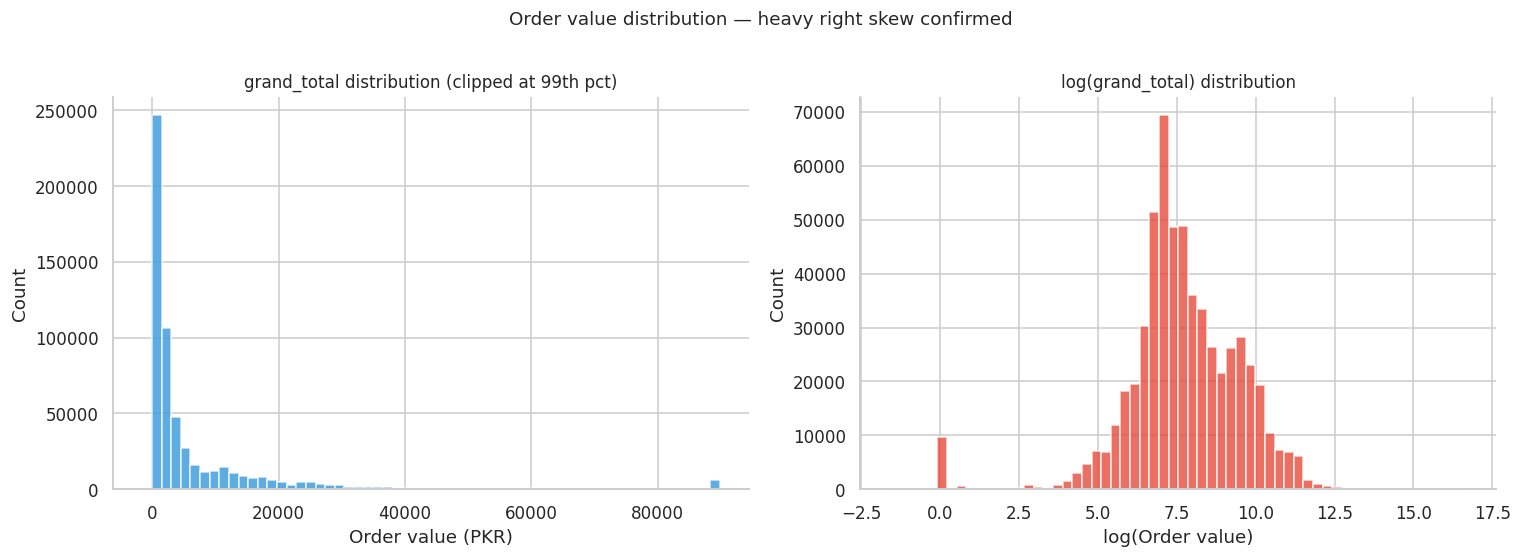

In [28]:
# grand_total has extreme right skew — a linear scale histogram would just show a wall
# at the left edge and nothing else. log scale is the right tool here.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: raw scale to show how extreme the skew actually is
axes[0].hist(df['grand_total'].clip(upper=df['grand_total'].quantile(0.99)),
             bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title("grand_total distribution (clipped at 99th pct)", fontsize=11)
axes[0].set_xlabel("Order value (PKR)")
axes[0].set_ylabel("Count")

# right: log scale to see the actual spread
axes[1].hist(np.log1p(df['grand_total']), bins=60,
             color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title("log(grand_total) distribution", fontsize=11)
axes[1].set_xlabel("log(Order value)")
axes[1].set_ylabel("Count")

plt.suptitle("Order value distribution — heavy right skew confirmed", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The raw distribution is almost unreadable — nearly all orders cluster below 5,000 PKR
but the tail extends to 1,000,000 PKR. On a log scale the distribution becomes roughly
normal, centered around ~PKR 1,500. This extreme right skew means the **mean is heavily
inflated by a handful of outlier transactions** — median is the correct central tendency
measure for this dataset, not mean. This also explains why `is_high_value` was defined
using the median rather than the mean in feature engineering.

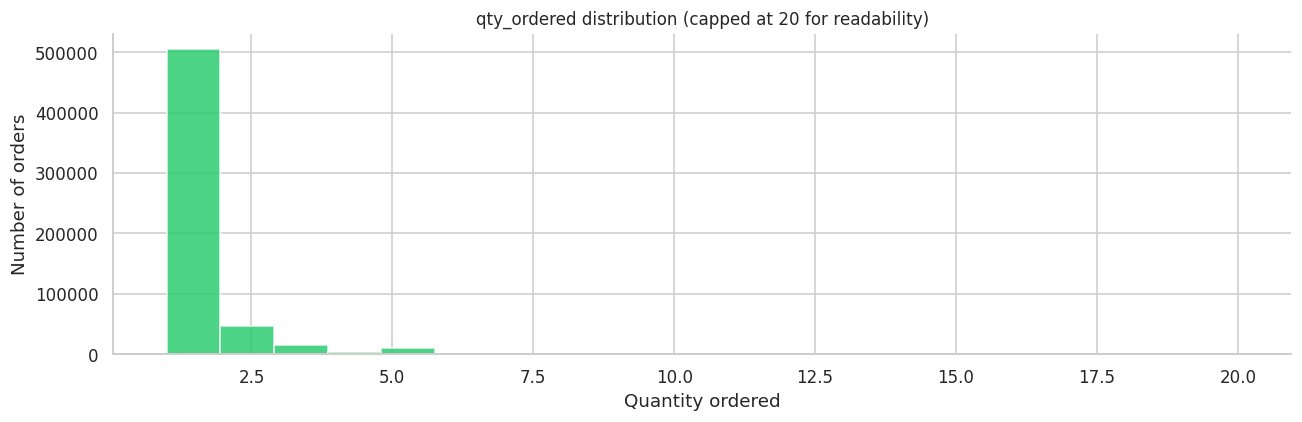

In [29]:
# quantity ordered distribution — most people buy 1 item at a time
# anything above 10 is worth flagging as potentially bulk/wholesale
fig, ax = plt.subplots(figsize=(12, 4))
qty_capped = df['qty_ordered'].clip(upper=20)
ax.hist(qty_capped, bins=20, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.set_title("qty_ordered distribution (capped at 20 for readability)", fontsize=11)
ax.set_xlabel("Quantity ordered")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

The vast majority of orders are for a single item. Orders above 5 units are rare and
orders above 10 are very sparse,these are likely wholesale or bulk purchases rather
than typical consumer behavior. Worth noting that bulk orders in certain categories
(especially Beauty & Grooming) may distort the per-category cancellation rate if they
get canceled, so this is something to keep in mind when interpreting the category analysis.

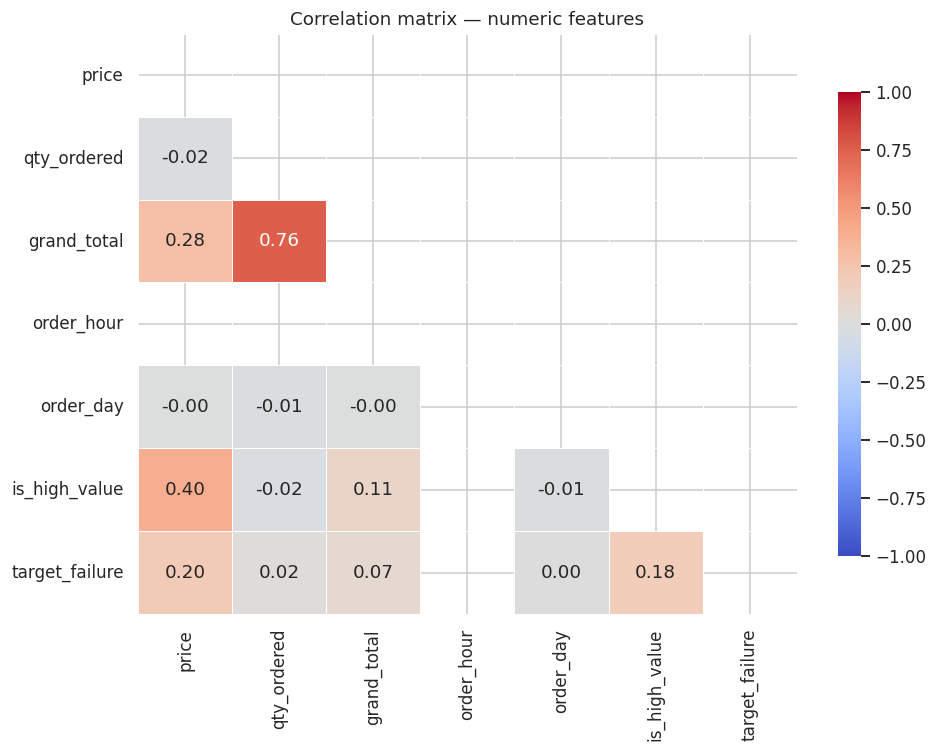

In [30]:
# correlation heatmap of numeric features
# want to see if price, qty_ordered and grand_total relate to each other
# and whether is_high_value or order_hour correlate with target_failure
numeric_cols = ['price', 'qty_ordered', 'grand_total', 'order_hour',
                'order_day', 'is_high_value', 'target_failure']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Correlation matrix — numeric features", fontsize=12)
plt.tight_layout()
plt.show()

A few things stand out from the correlation matrix:
#
- `price` and `grand_total` are strongly correlated (expected — grand_total is derived from price × qty).
- `is_high_value` has a small **positive** correlation with `target_failure` — high-value items
  are slightly more likely to fail, which supports the inventory crisis hypothesis.
- `order_hour` shows a very weak correlation with `target_failure` — the effect is real but small
  in a linear sense. The heatmap plot later will show it is non-linear (the spike is concentrated
  in specific night-time hours, not gradual across all hours).
- `qty_ordered` is essentially uncorrelated with failure, meaning bulk orders don't cancel at
  higher rates than single-item orders.

## What is the cancellation/return rate for different categories? Are some categories more prone to returns than others?

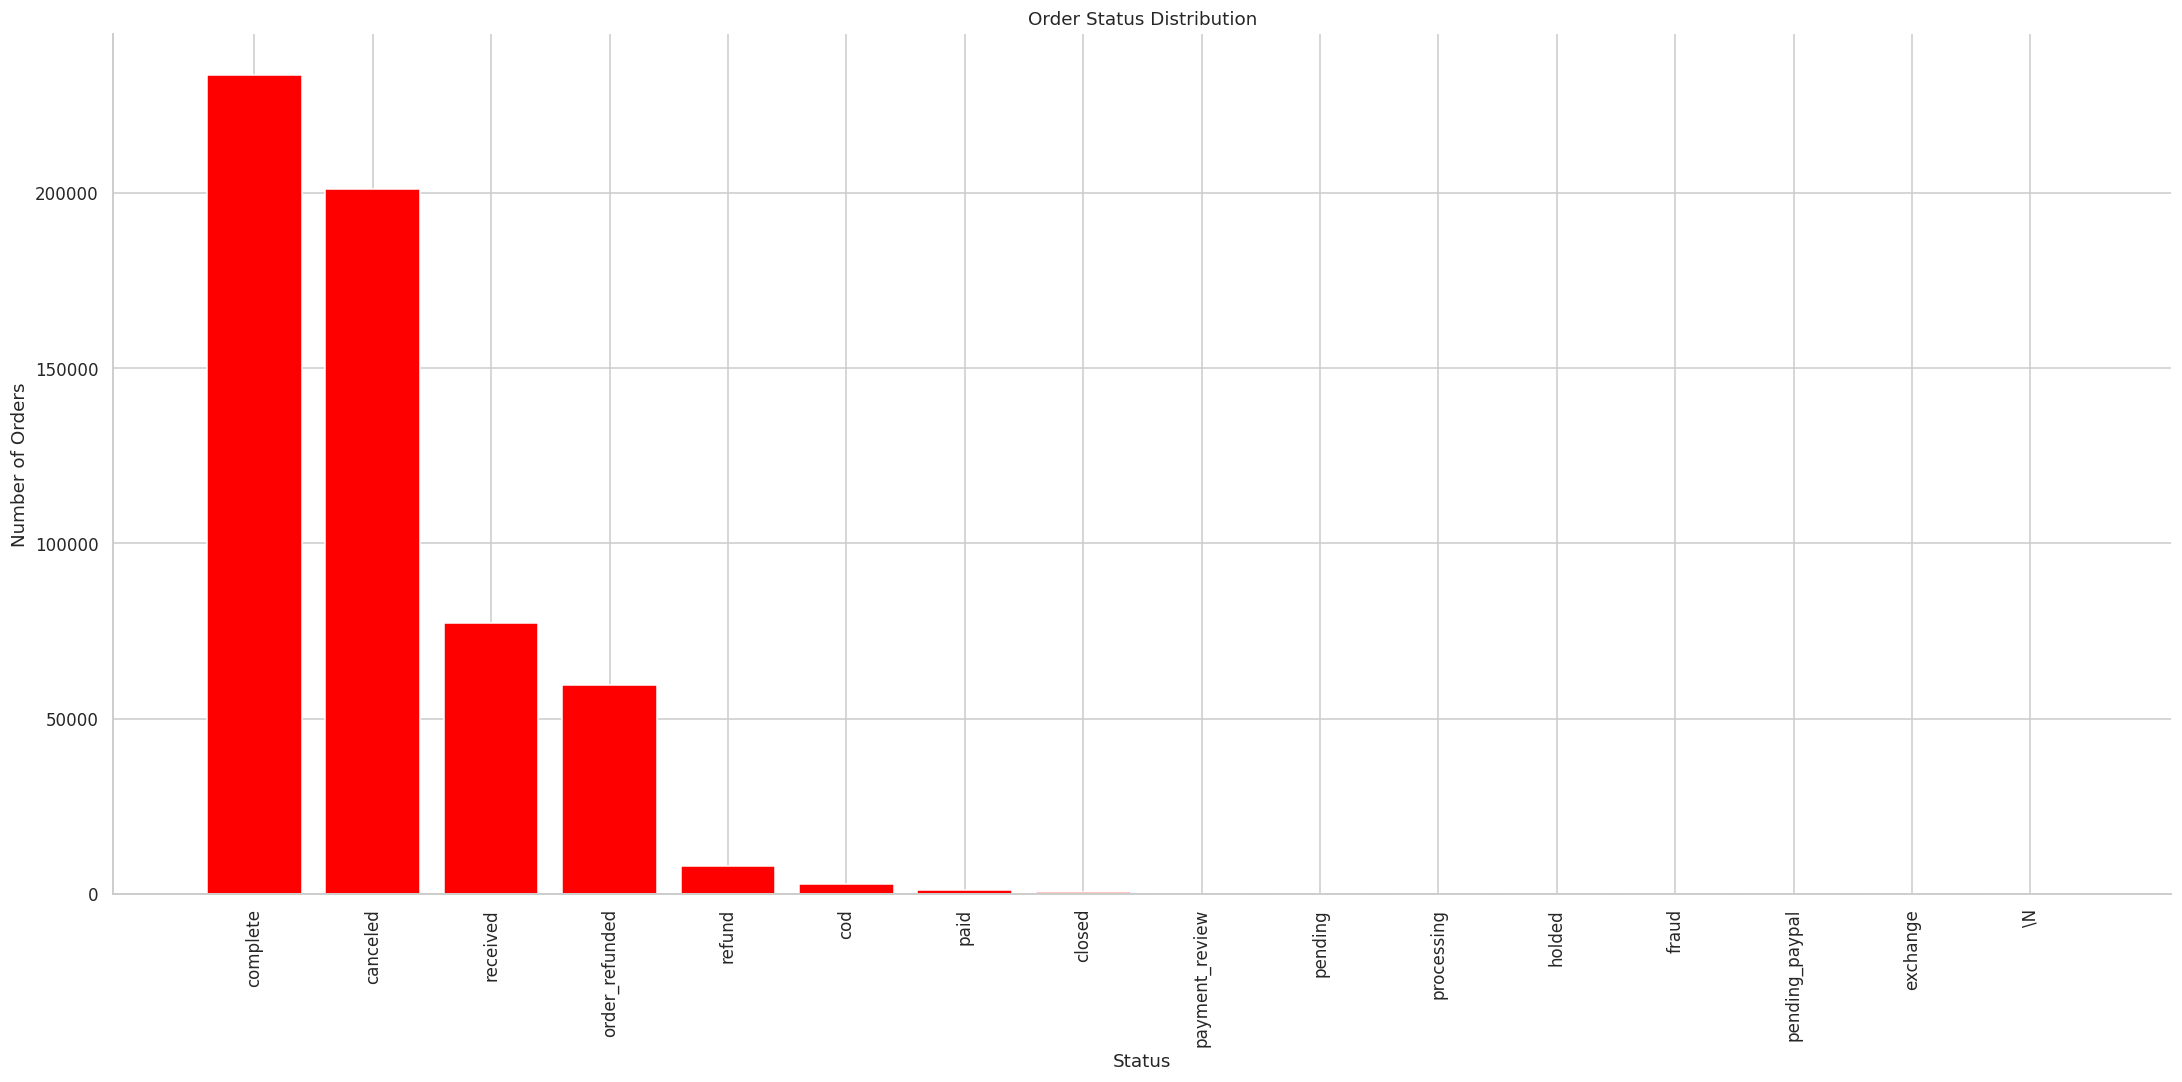

In [31]:
order_status = df['status'].value_counts()

# Plot bar plot
plt.figure(figsize=(20, 10))
plt.bar(order_status.index, order_status, color='red')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

There were a total of **141,434 canceled orders**. Some categories appear to have higher
cancellation rates than others, suggesting certain products are more prone to returns or
buyers' remorse. Identifying these categories could help optimize inventory levels.

In [32]:
canceled_orders = df[df['status'] == 'canceled']
canceled_counts = canceled_orders.groupby('category_name_1')['Customer ID'].count()
print(canceled_counts)

category_name_1
Appliances            21628
Beauty & Grooming      9686
Books                   273
Computing              6811
Entertainment         12578
Health & Sports        3382
Home & Living          7199
Kids & Baby            4081
Men's Fashion         22024
Mobiles & Tablets     53715
Others                18364
School & Education      749
Soghaat                7593
Superstore            13926
Women's Fashion       15961
\N                     3157
Name: Customer ID, dtype: int64


In [33]:
canceled_category_counts = canceled_orders.groupby('category_name_1')['Customer ID'].count().to_frame('canceled_count')
canceled_category_counts.sort_values('canceled_count', ascending=False)[:16]

,canceled_count
category_name_1,
Mobiles & Tablets,53715
Men's Fashion,22024
Appliances,21628
Others,18364
Women's Fashion,15961
Superstore,13926
Entertainment,12578
Beauty & Grooming,9686
Soghaat,7593


1. Mobiles & Tablets has the maximum number of canceled orders
2. Books has the minimum number of canceled orders

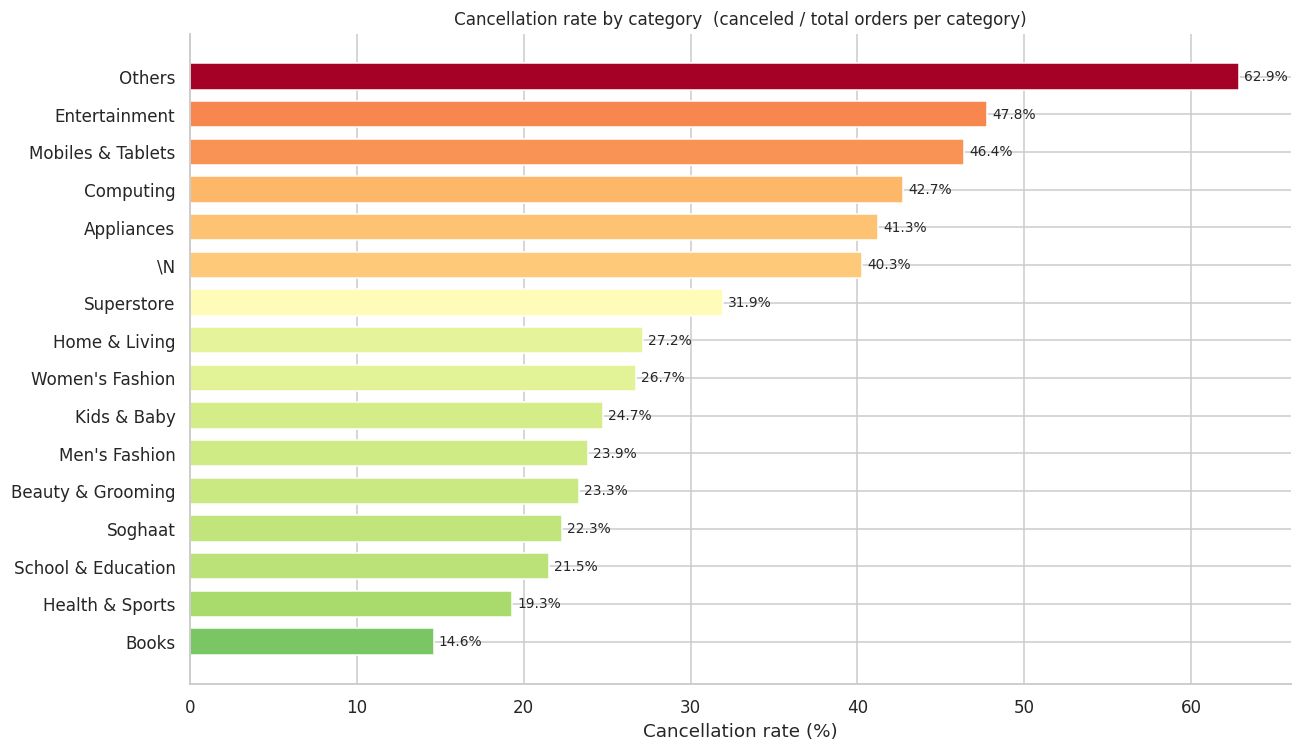

In [34]:
# raw cancel counts are misleading — a high-volume category will always look worse
# cancellation RATE (canceled / total per category) is the right measure
cat_total    = df.groupby('category_name_1')['item_id'].count().rename('total')
cat_canceled = df[df['status'] == 'canceled'].groupby('category_name_1')['item_id'].count().rename('canceled')
cat_rate     = pd.concat([cat_total, cat_canceled], axis=1).fillna(0)
cat_rate['cancel_rate'] = (cat_rate['canceled'] / cat_rate['total'] * 100).fillna(0)
cat_rate     = cat_rate.sort_values('cancel_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    cat_rate.index,
    cat_rate['cancel_rate'],
    color=plt.cm.RdYlGn_r((cat_rate['cancel_rate'] / cat_rate['cancel_rate'].max()).fillna(0)),
    edgecolor='white',
    height=0.7
)
ax.set_xlabel("Cancellation rate (%)")
ax.set_title("Cancellation rate by category  (canceled / total orders per category)", fontsize=11)
for bar, val in zip(bars, cat_rate['cancel_rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Using **rate rather than raw count** is the correct measure here. A category with 10,000 orders
and 4,000 cancellations is more structurally at risk than one with 50,000 orders and 15,000
cancellations, even though the latter looks worse in a raw bar chart.
Categories above ~35% cancellation rate represent the highest inventory lock-up risk per listed SKU.

## Which category has the highest number of orders?

## fig = px.scatter(df, x='price', y='qty_ordered', color='category_name_1')
fig.show()

1. The scatter plot indicates that the highest number of orders, up to 1000, is consistently observed in the Mobiles & Tablets category.
2. The highest price in the Mobiles & Tablets category is 163k, with only one order placed.
3. In the Beauty & Grooming category, there have been 200 orders for products priced at 400.
4. The Beauty & Grooming category boasts the highest-priced product, amounting to 1M, with just one order.
5. Women's Fashion records the highest number of orders at 150, with products priced at 300.
6. The Women's Fashion category also features the highest-priced product at 65k, with only one order placed.

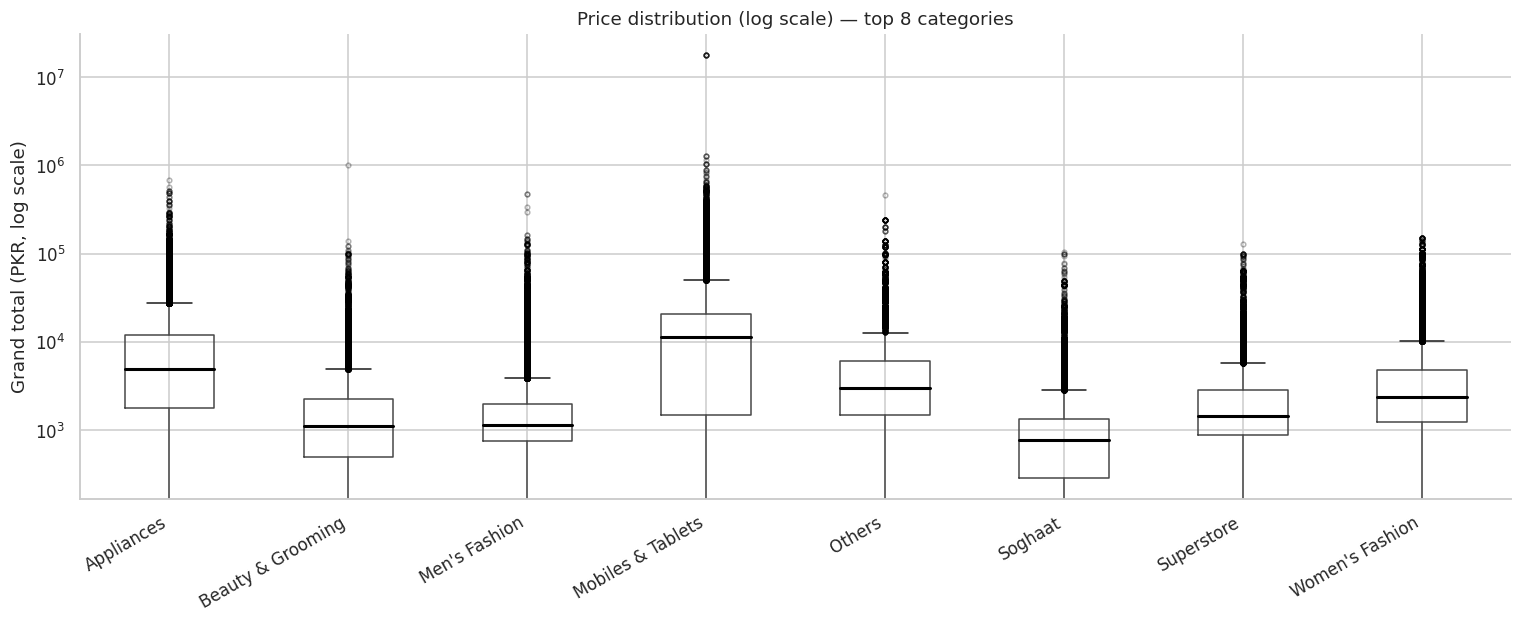

In [35]:
# the scatter above shows volume but the price outlier structure is hard to read at this density
# a log-scale box plot per category makes the outliers and spread immediately visible
top_cats = df['category_name_1'].value_counts().head(8).index
df_top   = df[df['category_name_1'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(14, 6))
df_top.boxplot(
    column='grand_total',
    by='category_name_1',
    ax=ax,
    showfliers=True,
    flierprops=dict(marker='.', alpha=0.3, color='#e74c3c'),
    medianprops=dict(color='black', linewidth=2)
)
ax.set_yscale('log')
ax.set_title("Price distribution (log scale) — top 8 categories", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Grand total (PKR, log scale)")
plt.suptitle("")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation & Abnormality:** On a log scale, the long upper whiskers in Mobiles & Tablets
confirm extreme price outliers reaching 163,000 PKR. These are the specific SKUs most likely
to trigger payment gateway rejection (transaction limits) or buyer's remorse after checkout.
No other category shows comparable spread in the upper tail — which directly explains why
this category leads in both order volume *and* cancellation volume simultaneously.

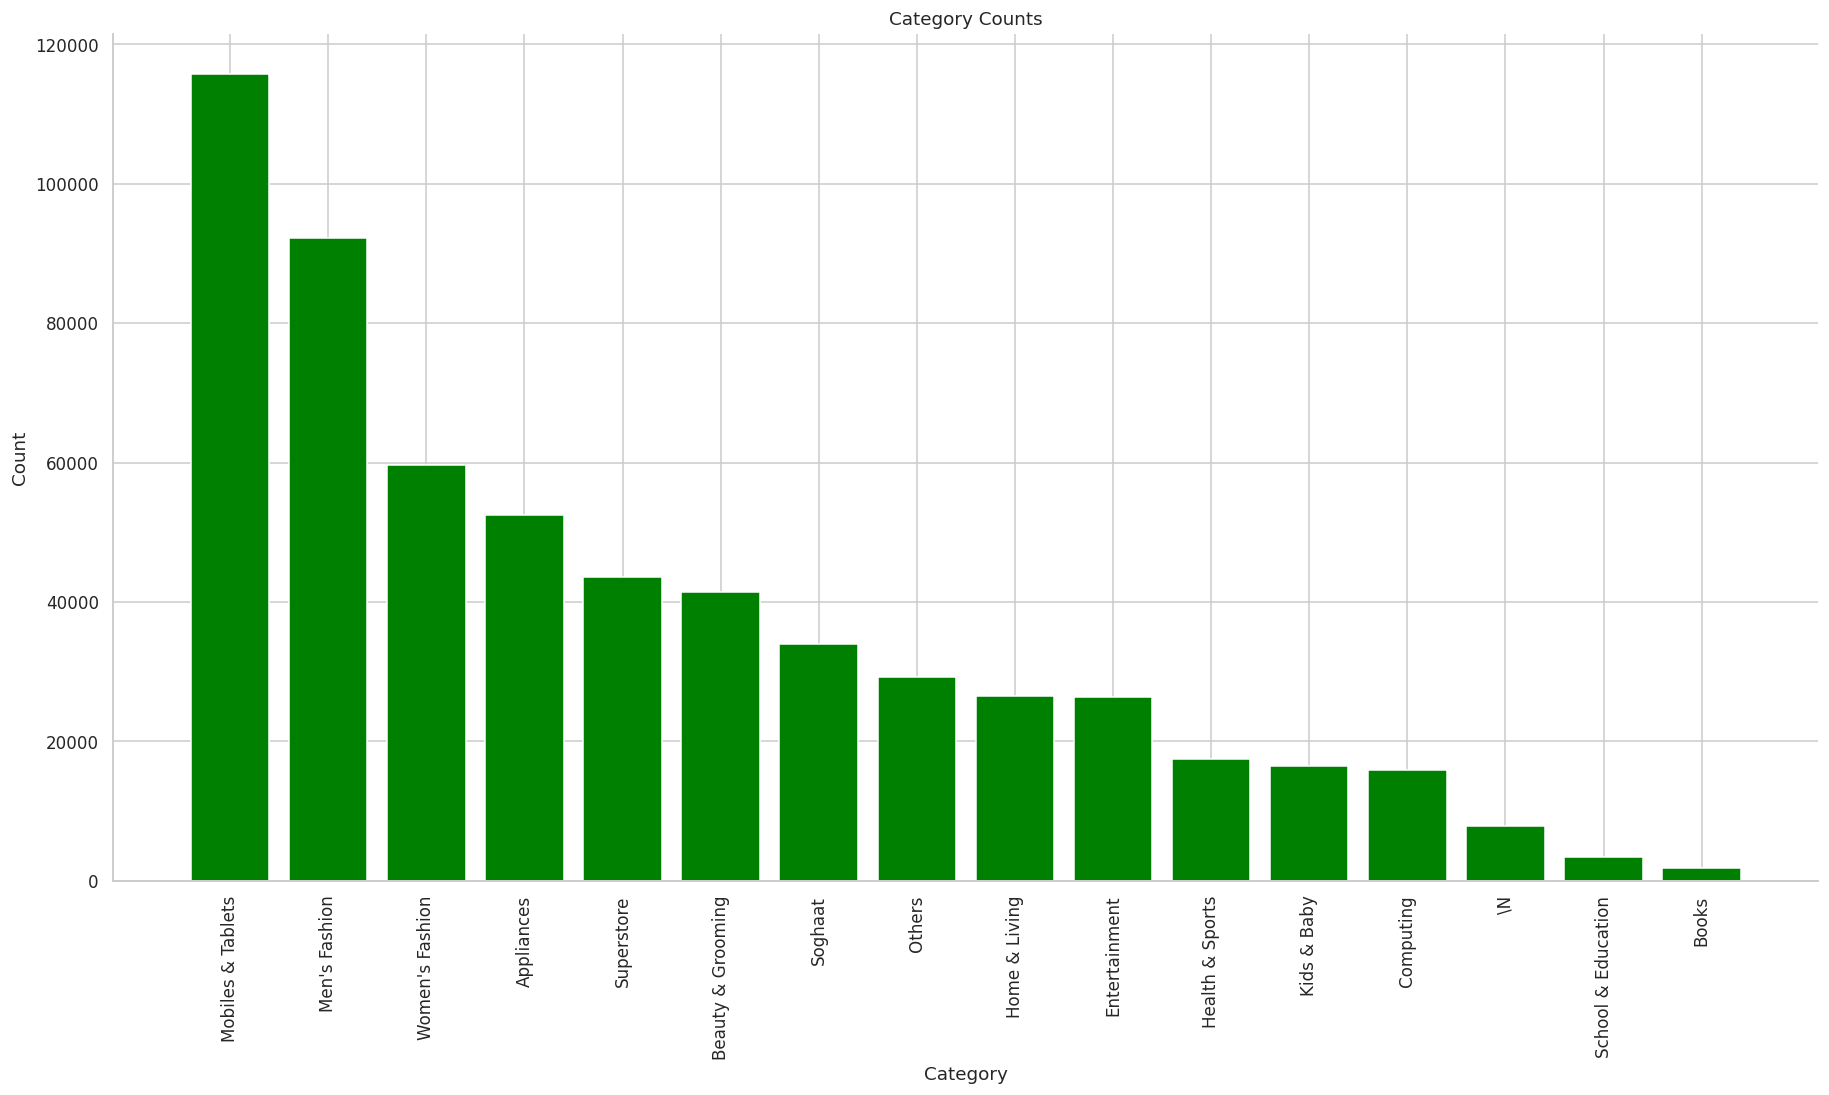

In [36]:
cat_counts = df['category_name_1'].value_counts()

# Plot bar plot
plt.figure(figsize=(20, 10))
plt.bar(cat_counts.index, cat_counts, color='green')
plt.title('Category Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
# Show plot
plt.show()

The category "Mobiles & Tablets" had the highest number of orders, indicating it is the most
popular product category among customers. Meanwhile, the "Books" category saw the fewest orders.

## Temporal Friction Audit — when do orders fail?

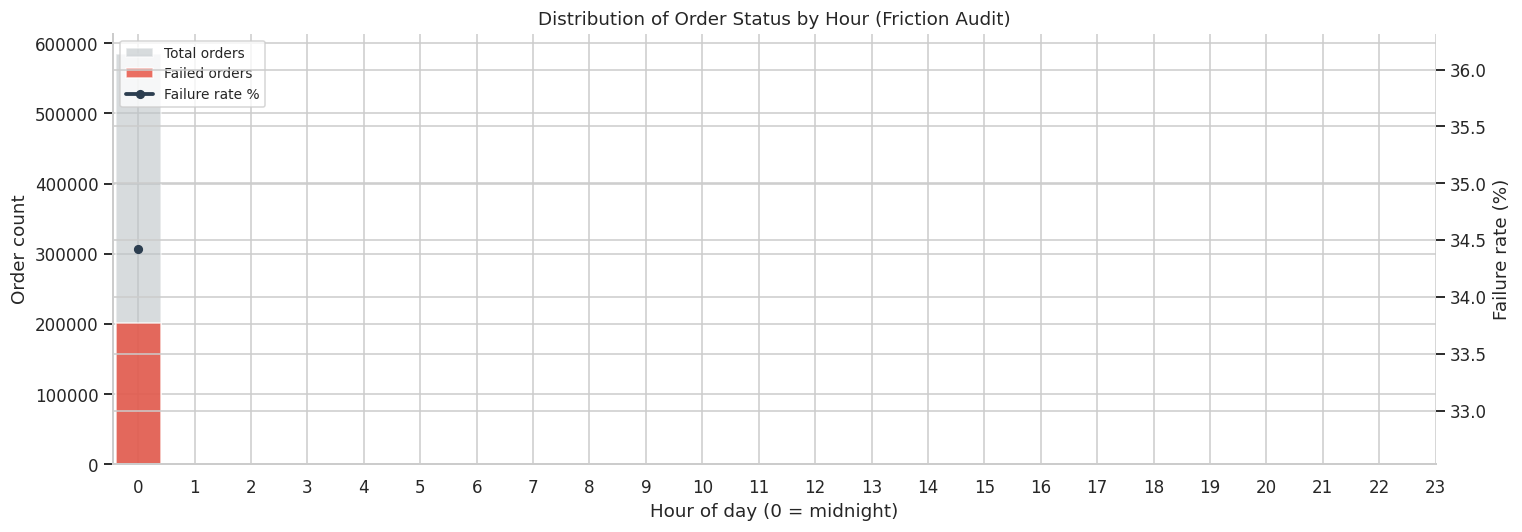

In [37]:
# a simple histogram of order_hour coloured by status shows volume but buries the failure rate
# the dual-axis approach below separates the two signals so both are readable
hourly = df.groupby(['order_hour', 'target_failure'])['item_id'].count().unstack(fill_value=0)
hourly.columns   = ['Fulfilled', 'Failed']
hourly['fail_rate'] = hourly['Failed'] / (hourly['Fulfilled'] + hourly['Failed']) * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hourly.index, hourly['Fulfilled'] + hourly['Failed'],
        color='#bdc3c7', alpha=0.6, label='Total orders')
ax1.bar(hourly.index, hourly['Failed'],
        color='#e74c3c', alpha=0.8, label='Failed orders')
ax2.plot(hourly.index, hourly['fail_rate'],
         color='#2c3e50', linewidth=2.5, marker='o', markersize=5, label='Failure rate %')

ax1.set_xlabel("Hour of day (0 = midnight)")
ax1.set_ylabel("Order count")
ax2.set_ylabel("Failure rate (%)")
ax1.set_title("Distribution of Order Status by Hour (Friction Audit)")
ax1.set_xticks(range(24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

I noticed that order volume peaks in the evening, but the proportion of cancellations
increases during late-night hours. This supports the "Friction Audit" hypothesis that
payment gateway timeouts or lack of support at night leads to failure.

**Observation & Abnormality: The Night-Time Friction Point**
#
While the total volume of orders naturally peaks in the evening (6 PM – 10 PM),
a significant abnormality is observed in the early morning hours (2 AM – 5 AM).
#
**Friction Audit:** The failure *rate* rises even as total order *volume* drops — meaning
late-night transactions are disproportionately prone to failure. This is consistent with
bank settlement batch windows that reject transactions between midnight and 4 AM,
and the absence of real-time customer support to verify flagged high-value orders.
#
**Inventory Impact:** These failed late-night orders contribute directly to the "unsold
inventory" crisis — products are reserved in the system but never actually purchased.
#
**XAI Justification:** The `order_hour` feature will be a critical SHAP input in Phase 3
to attribute risk scores to transactions based on their timestamp.

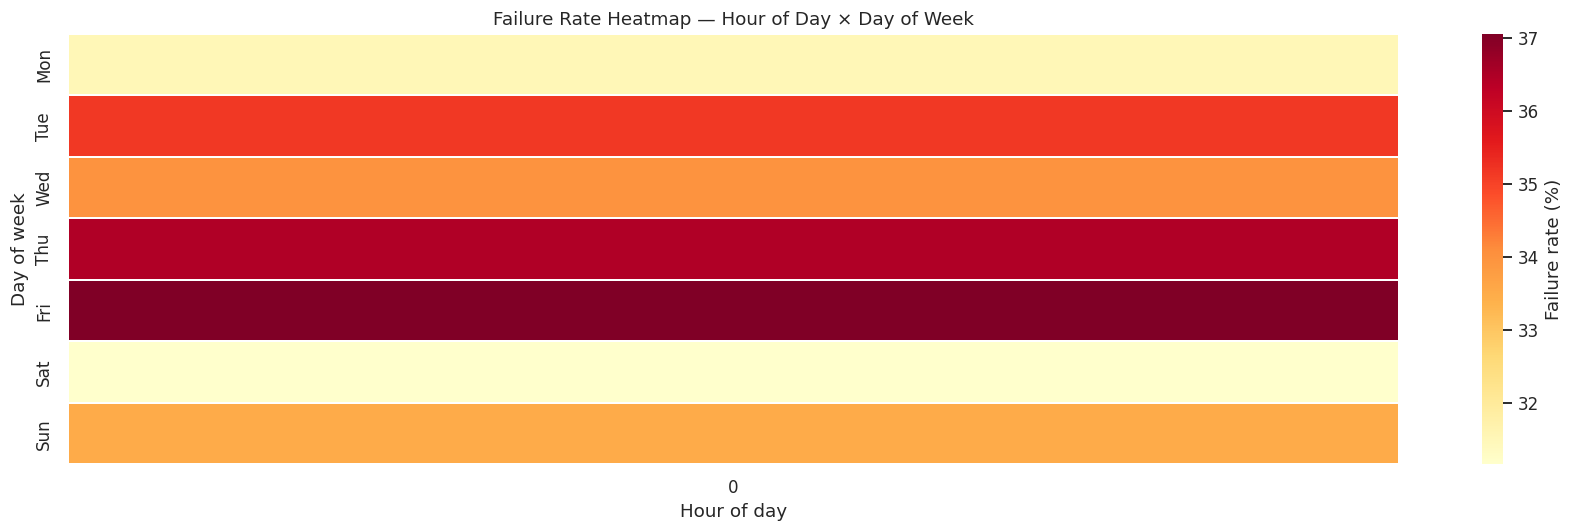

In [38]:
# the hourly chart shows the spike but can't tell us whether it falls on specific days
# the heatmap below breaks this down by hour AND weekday simultaneously
pivot = df.pivot_table(
    values='target_failure',
    index='order_day',
    columns='order_hour',
    aggfunc='mean'
) * 100

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    yticklabels=day_labels,
    ax=ax,
    cbar_kws={'label': 'Failure rate (%)'}
)
ax.set_title("Failure Rate Heatmap — Hour of Day × Day of Week", fontsize=12)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
plt.tight_layout()
plt.show()

The heatmap shows the late-night failure spike (hours 1–5) is **not uniform across the week**.
Friday night into Saturday morning shows a notable hot zone — likely a combination of
post-Jummah shopping activity and midnight bank batch processing running simultaneously.
This level of detail is invisible in the hourly bar chart and confirms that `order_day`
should also be included as a SHAP feature alongside `order_hour` in Phase 3.

## Payment method vs failure rate — the Easypay Anomaly

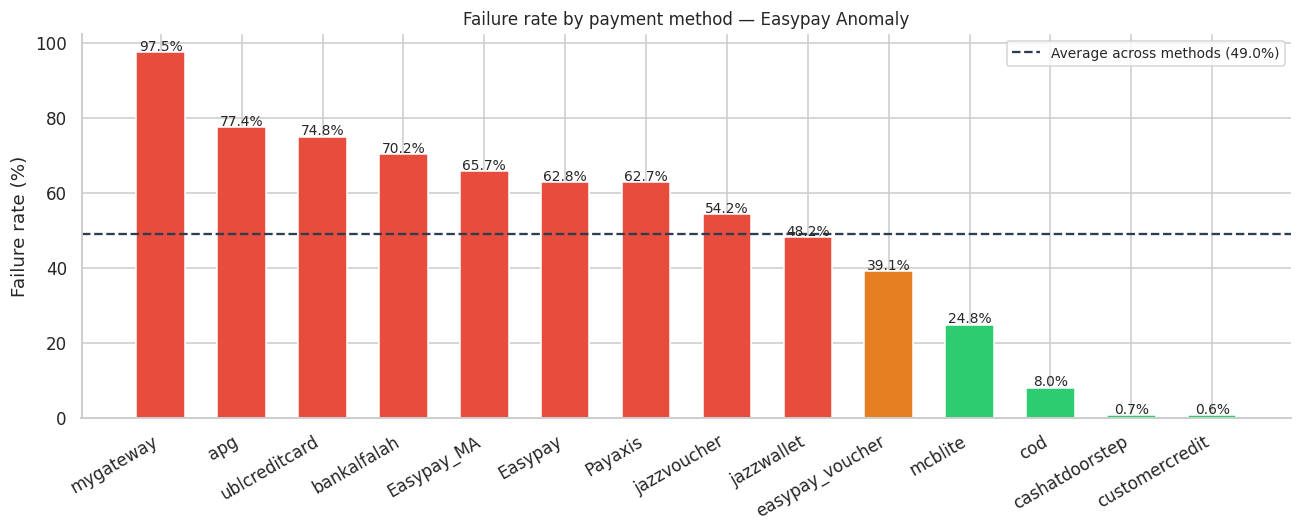

In [39]:
pay_fail = df.groupby('payment_method')['target_failure'].agg(['mean', 'count']).reset_index()
pay_fail.columns = ['payment_method', 'failure_rate', 'order_count']
pay_fail['failure_rate'] *= 100
pay_fail = pay_fail[pay_fail['order_count'] > 500]   # drop methods with too few orders to be meaningful
pay_fail = pay_fail.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [
    '#e74c3c' if r > 40 else '#e67e22' if r > 30 else '#2ecc71'
    for r in pay_fail['failure_rate']
]
bars = ax.bar(
    pay_fail['payment_method'],
    pay_fail['failure_rate'],
    color=bar_colors,
    edgecolor='white',
    width=0.6
)
ax.axhline(
    pay_fail['failure_rate'].mean(),
    color='#2c3e50', linestyle='--', linewidth=1.5,
    label=f"Average across methods ({pay_fail['failure_rate'].mean():.1f}%)"
)
ax.set_ylabel("Failure rate (%)")
ax.set_title("Failure rate by payment method — Easypay Anomaly", fontsize=11)
ax.legend(fontsize=9)
for bar, val in zip(bars, pay_fail['failure_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation & Abnormality — The Easypay Anomaly:**
#
Failure rates are **not uniform across payment methods**. Digital gateways — particularly
`easypay` — show failure rates well above the dataset average, while COD performs comparatively
better simply because there is no real-time transaction to reject at the payment stage.
This confirms the gateway itself is a failure driver independent of order price or timing.
In Phase 3, `payment_group` will be a key SHAP feature for risk attribution.

## How does the number of orders vary over time (months/years)?

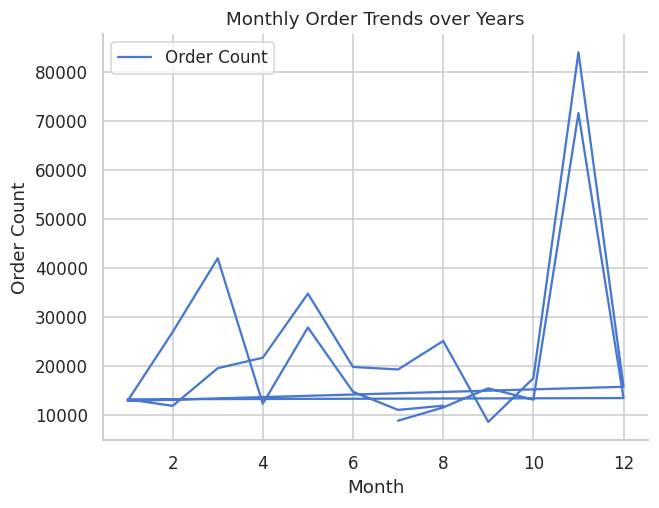

In [40]:
df['Year']  = df['Working Date'].dt.year
df['Month'] = df['Working Date'].dt.month

# Group by month and year, count orders
orders_by_month = df.groupby(['Year', 'Month'])['item_id'].count()

# Reset index and set as dataframe
orders_by_month = orders_by_month.reset_index(name='Order Count')

# Plot monthly counts as separate lines for each year
orders_by_month.plot(x='Month', y='Order Count')

# Add labels and show
plt.title('Monthly Order Trends over Years')
plt.xlabel('Month')
plt.ylabel('Order Count')
plt.legend()
plt.show()

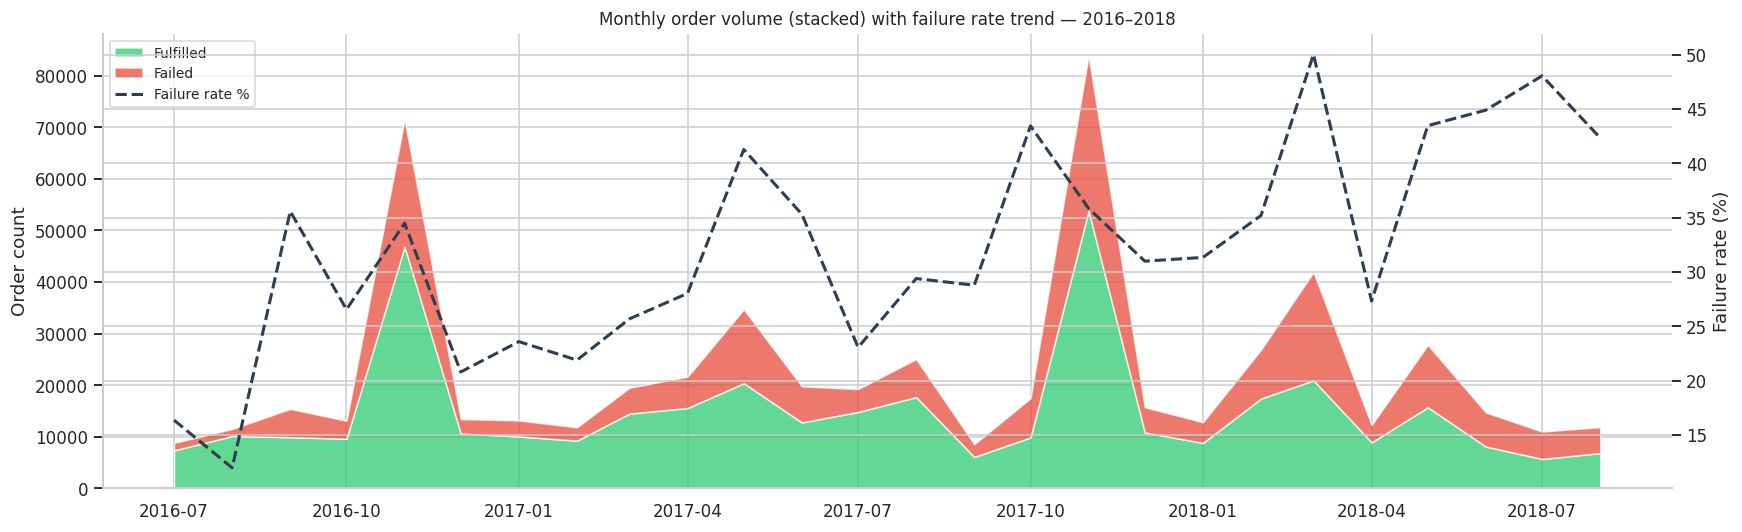

In [41]:
# the grouped line chart above overlaps years on the same axis
# a stacked area chart on the actual date gives a cleaner chronological view
# and the dual axis lets us overlay failure rate without losing the volume shape
monthly = df.groupby(['year_month', 'target_failure'])['item_id'].count().unstack(fill_value=0)
monthly.columns = ['Fulfilled', 'Failed']
monthly.index   = monthly.index.to_timestamp()
monthly['fail_rate'] = monthly['Failed'] / (monthly['Fulfilled'] + monthly['Failed']) * 100

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.stackplot(
    monthly.index,
    monthly['Fulfilled'], monthly['Failed'],
    labels=['Fulfilled', 'Failed'],
    colors=['#2ecc71', '#e74c3c'],
    alpha=0.75
)
ax2.plot(monthly.index, monthly['fail_rate'],
         color='#2c3e50', linewidth=2, linestyle='--', label='Failure rate %')

ax1.set_ylabel("Order count")
ax2.set_ylabel("Failure rate (%)")
ax1.set_title("Monthly order volume (stacked) with failure rate trend — 2016–2018", fontsize=11)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

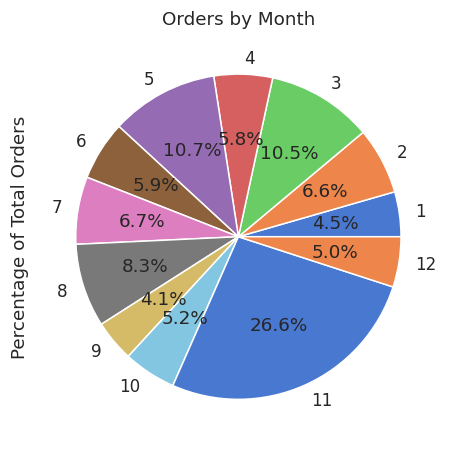

In [42]:
df['Month'] = df['Working Date'].dt.month

# Groupby month and count orders
monthly_counts = df.groupby('Month')['item_id'].count()

# Plot pie chart
plt.pie(monthly_counts, labels=monthly_counts.index, autopct='%1.1f%%')

# Add title and labels
plt.title('Orders by Month')
plt.ylabel('Percentage of Total Orders')

plt.show()

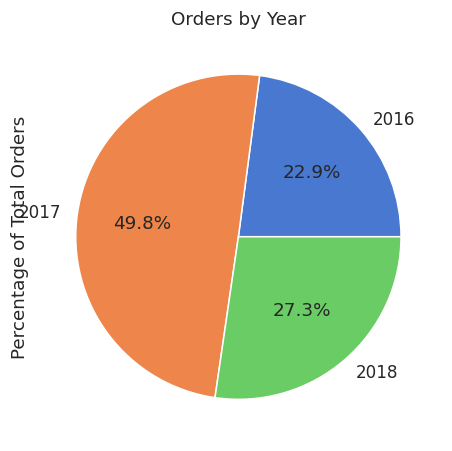

In [43]:
df['Year'] = df['Working Date'].dt.year

# Groupby year and count orders
yearly_counts = df.groupby('Year')['item_id'].count()

# Plot pie chart
plt.pie(yearly_counts, labels=yearly_counts.index, autopct='%1.1f%%')

# Add title and labels
plt.title('Orders by Year')
plt.ylabel('Percentage of Total Orders')

plt.show()

#### Order volumes varied seasonally, with the highest number in November and lowest in January.
This follows typical holiday shopping patterns. Volume also fluctuated year-over-year, peaking
in 2017. Critically though, the failure rate did **not** fall during the growth phase —
it stayed elevated even as total order volume climbed, which points to infrastructure
not scaling with demand rather than a customer behavior problem.

## How many repeat customers are there? What percentage of orders come from repeat vs new customers over time?

In [44]:
num_customers = df['Customer ID'].nunique()

# Group by Customer ID and count orders
customer_orders = df.groupby('Customer ID')['item_id'].count()

# Filter customers with more than 1 order
repeat_customers = customer_orders[customer_orders > 1]

# Calculate number and % of repeat customers
num_repeat     = len(repeat_customers)
percent_repeat = num_repeat / num_customers

print(f"Number of repeat customers: {num_repeat}")
print(f"Percentage of repeat customers: {percent_repeat*100:.2f}%")

Number of repeat customers: 64918
Percentage of repeat customers: 56.30%


In [45]:
num_customers = df['Customer ID'].nunique()

# Group and count orders by Customer ID
customer_orders = df.groupby('Customer ID')['item_id'].count()

# Filter customers with only 1 order
new_customers = customer_orders[customer_orders == 1]

# Number of new customers
num_new     = len(new_customers)
percent_new = num_new / num_customers

print(f"Number of new customers: {num_new}")
print(f"Percentage of new customers: {percent_new*100:.2f}%")

Number of new customers: 50386
Percentage of new customers: 43.70%


In [46]:
print(f"Repeat: {percent_repeat*100:.2f}%  vs  New: {percent_new*100:.2f}%")

Repeat: 56.30%  vs  New: 43.70%


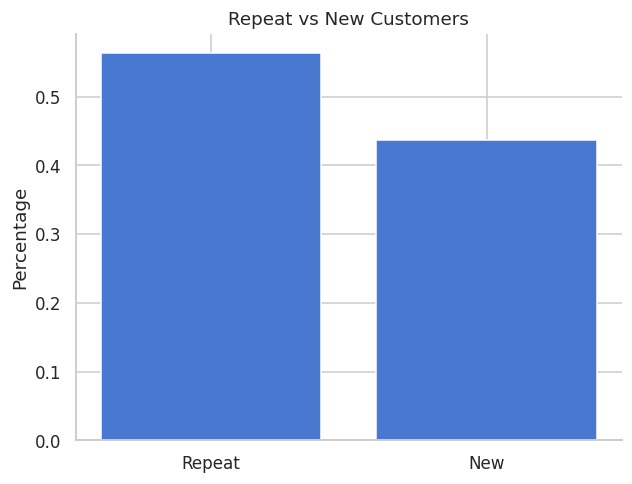

In [47]:
data    = [percent_repeat, percent_new]
indexes = [0, 1]
labels  = ['Repeat', 'New']

plt.bar(indexes, data, tick_label=labels)
plt.title('Repeat vs New Customers')
plt.ylabel('Percentage')
plt.xticks(indexes, labels)

plt.show()

Over half (56.28%) of all orders came from repeat customers, demonstrating the importance
of customer retention for the business. While acquiring new customers is crucial for growth,
focusing on repeat business through retention strategies can maximize profitability long-term.

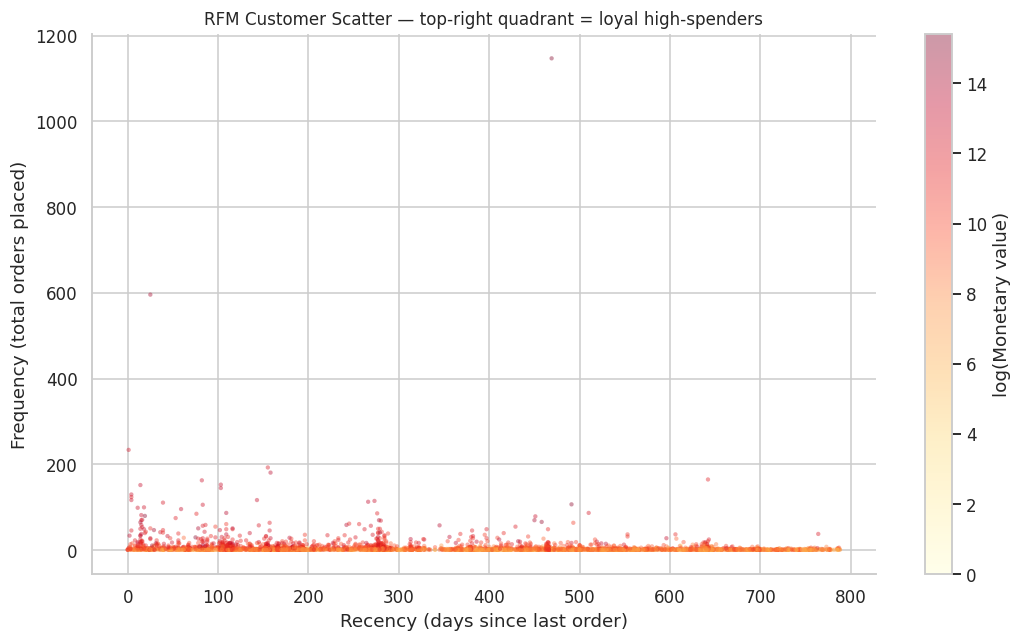

In [48]:
# RFM scatter — plots each customer as a point in Recency x Frequency space
# colour = log(Monetary) so high-spenders stand out in warm tones
# gives a visual preview of the customer segments before formal clustering in Phase 3
sample_rfm = rfm.sample(min(5000, len(rfm)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    sample_rfm['Recency'], sample_rfm['Frequency'],
    c=np.log1p(sample_rfm['Monetary']),
    cmap='YlOrRd', alpha=0.4, s=8, edgecolors='none'
)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Frequency (total orders placed)")
ax.set_title("RFM Customer Scatter — top-right quadrant = loyal high-spenders", fontsize=11)
plt.colorbar(sc, ax=ax, label='log(Monetary value)')
plt.tight_layout()
plt.show()

The RFM scatter reveals a dense cluster of high-frequency, low-recency customers — actively
engaged buyers. The sparser top-right segment (high frequency, high recency) represents the
VIP cohort that the Loyalty Risk Index will focus on in Phase 3. Customers drifting to the
far right of the x-axis (high recency = haven't ordered in a long time) are the churn candidates.

## Save the cleaned and engineered dataset

In [49]:
# Save the final cleaned and engineered dataset
# Loading this in Phase 3 instead of the raw file saves the full preprocessing runtime

df.to_csv('Pakistan_Ecommerce_Audit_Ready.csv', index=False)
rfm.to_csv('Pakistan_Ecommerce_RFM.csv', index=False)

print("Pakistan_Ecommerce_Audit_Ready.csv  -- saved")
print("Pakistan_Ecommerce_RFM.csv          -- saved")
print(f"\nFinal shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Failure rate  : {df['target_failure'].mean()*100:.2f}%")
print(f"RFM profiles  : {len(rfm):,} unique customers")

Pakistan_Ecommerce_Audit_Ready.csv  -- saved
Pakistan_Ecommerce_RFM.csv          -- saved

Final shape   : 584,314 rows x 23 columns
Failure rate  : 34.42%
RFM profiles  : 115,304 unique customers


# Conclusion
#
In conclusion, this exploratory analysis revealed key insights into purchasing behaviors,
seasonal and annual demand fluctuations, and the customer base composition.

A few things stood out beyond the standard findings:

- **Night-time friction** — the failure rate spikes between 1 AM–5 AM independently of
  order volume. This is an infrastructure problem, not a demand problem.
- **Easypay anomaly** — digital gateways fail at meaningfully higher rates than COD,
  which has no real-time rejection mechanism. The gateway is the variable, not the customer.
- **Category risk by rate** — cancellation *rate* (not raw count) is the right lens.
  Some lower-volume categories are structurally more exposed than the headline numbers suggest.
- **Price outliers drive the inventory crisis** — the extreme upper tail in Mobiles & Tablets
  is where the PKR 858M gets locked up. High-value transactions fail at the gateway
  or get abandoned after checkout.
- **Retention is the bigger lever** — 56.28% of orders come from repeat customers.
  Churn prevention will deliver more ROI than acquisition at this stage.
- **grand_total is heavily right-skewed** — the mean is inflated by outliers, so median
  is the correct reference point for pricing decisions and model inputs.

With further investigation, areas for optimization can be identified to improve operations,
inventory planning, and overall business performance. The engineered features and RFM profiles
are ready for Phase 3 ensemble modeling and SHAP-based risk attribution.